C:\Users\10445\anaconda3\envs\new_env\lib\site-packages\dask\dataframe\_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 13.0.0. Please consider upgrading.
  warnings.warn(


corr_PE_swi_dwi
 1.0    67.073171
-1.0    32.926829
Name: proportion, dtype: float64


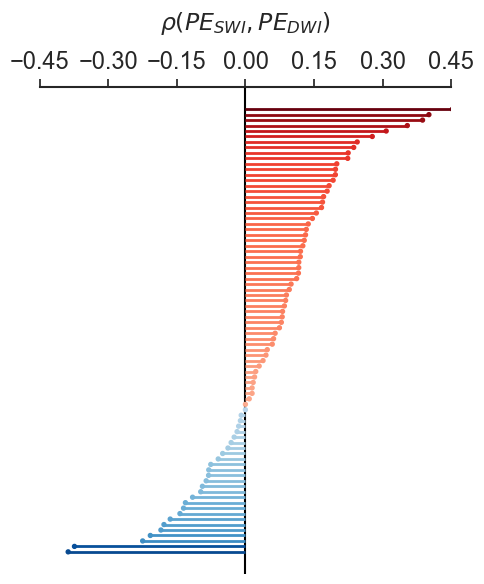

In [3]:
import pandas as pd
import numpy as np
import time
import io
import geopandas
from shapely.geometry import Point,LineString, Polygon
import shapely
import warnings
from sklearn.cluster import OPTICS,DBSCAN
import pyproj
from collections import Counter,defaultdict
import math
from datetime import datetime, timedelta
from shapely.geometry import MultiPolygon,box
from geopandas.geodataframe import GeoDataFrame
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cmx
import matplotlib.patches as mpatches
import requests
import os
import json
import dask.dataframe as dd # 并行计算库
import random
import pickle
import statsmodels.api as sm
import networkx as nx
import osmnx as ox
from scipy.spatial import cKDTree
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from streamlit import header
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra, connected_components
import rasterio
from rasterio import mask as rio_mask
from shapely.geometry import mapping
import seaborn as sns



import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

city_df = pd.read_csv(
    f'E:\experienced segregation in 15 min cities\Code and Data\source data\City_Morphology_Correlation.csv')

ratio_series = np.sign(city_df['corr_PE_swi_dwi']).value_counts(normalize=True) * 100

print(ratio_series)

# 1. 对数据按 'diff' 列降序排序，并重置索引
city_df_sorted = city_df.sort_values(by='corr_PE_swi_dwi', ascending=False).reset_index(drop=True)

# 2. 颜色映射逻辑 (大于0红，小于0蓝，绝对值越大颜色越深)
# 找出绝对值的最大值，用于归一化计算深浅
max_abs = city_df_sorted['corr_PE_swi_dwi'].abs().max()


def get_color(val, max_val):
    if val == 0:
        return 'gray'

    # 计算深浅比例 (0 到 1之间)
    # 为了防止接近 0 的数值颜色太浅（变成白色看不清），我们将起点设为 0.3
    intensity = 0.3 + 0.7 * (abs(val) / max_val)

    if val > 0:
        return plt.cm.Reds(intensity)  # 调用系统自带的红色渐变色带
    else:
        return plt.cm.Blues(intensity)  # 调用系统自带的蓝色渐变色带


# 为每一行生成对应的颜色
colors = [get_color(val, max_abs) for val in city_df_sorted['corr_PE_swi_dwi']]
# 3. 设置绘图风格并创建画布
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(5, 6))

# 4. 绘制水平线条，传入我们刚刚生成的颜色列表
# linewidth 控制线条粗细，你可以根据需要调大
ax.hlines(y=city_df_sorted.index, xmin=0, xmax=city_df_sorted['corr_PE_swi_dwi'],
          colors=colors, linewidth=2)

# (可选) 在线条末端加上小圆点，让图表看起来更精致。不需要可以注释掉
ax.scatter(city_df_sorted['corr_PE_swi_dwi'], city_df_sorted.index, color=colors, s=8, zorder=3)

# 5. 边框与坐标轴修饰
# 去除右边、下边、以及你要求去掉的左边边框
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 保留上边框并加粗，作为 T 字形的 "横"
ax.spines['top'].set_visible(True)
ax.spines['top'].set_linewidth(1.5)

# 将 X 轴刻度和标签移到上方
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# 【新增修改】：设置 X 轴的刻度标签大小为 10
ax.tick_params(axis='x', labelsize=17)

# 彻底隐藏 Y 轴（纵坐标轴）的刻度和标签
ax.set_yticks([])
ax.set_ylabel('')  # 清空 Y 轴标题

# 翻转 Y 轴，让数值大的在上方，依次往下排列
ax.invert_yaxis()

# 设置 X 轴的对称范围，让 0 保持在正中间
ax.set_xlim([-0.45, 0.45])
ax.set_xticks([-0.45, -0.3, -0.15, 0, 0.15, 0.3, 0.45])
# 6. 绘制 T 字形的 "竖" (在 X=0 处画一条贯穿的黑色实线)
ax.axvline(0, color='black', linewidth=1.5, zorder=1)

ax.set_xlabel(r"$\rho(\mathit{PE}_{\mathit{SWI}}, \mathit{PE}_{\mathit{DWI}})$", fontsize=17, fontweight='bold',
              labelpad=15)

plt.tight_layout()
plt.savefig('F:/corr_PE_swi_dwi.svg', bbox_inches='tight')
plt.show()